# Within-Participant 2-Class — CNN-ResBiGRU Arm Curl vs Bench Press Classifier

**Based on:** Mekruksavanich & Jitpattanakul (2024), *Appl. Syst. Innov.*, 7(4), 59.

**Goal:** train a binary classifier (arm curls vs bench presses) *within* each participant, using only the team's own gym-collected data (`OurData`). Instead of asking "can the model generalise across people?", this notebook asks a simpler, more targeted question:

> *For a single participant, if we train on most of their exercise sets, can the model distinguish arm curls from bench presses on the remaining held-out sets?*

Each of the 5 participants (15–19) contributed 8 arm curl IDs (2 sets × 4 curl exercises) and 12 bench press IDs (2 sets × 6 bench press exercises). For each participant we randomly hold out 1 curl ID and 2 bench press IDs as the test set, train on the remaining 17 IDs, evaluate, and repeat this 3 times with different random holdouts to get mean ± std accuracy. The entire procedure runs independently for each participant — 5 participants × 3 repeats = 15 total model trains.

**Data source:** `OurData_v5_scaled_{Hz}Hz.csv` only — no golden dataset.

---
## 1. Imports and setup

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from scipy.signal import butter, filtfilt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)
import matplotlib.pyplot as plt
import re, os, warnings
warnings.filterwarnings("ignore")
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"PyTorch: {torch.__version__}")
print(f"CUDA:    {torch.cuda.is_available()}")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device:  {DEVICE}")

PyTorch: 2.10.0+cu128
CUDA:    True
Device:  cuda


---
## 2. Configuration

This is a **binary classification** problem: arm curl family (parent = 1, label 0) vs bench press family (parent = 5, label 1). All 10 individual exercises collapse into these two parent classes.

- **`NUM_CLASSES = 2`** — we classify by parent classes, not individual exercises (i.e., child classes).
- **`LABEL_MAP = {1: 0, 5: 1}`** — maps the `parent` column directly to binary labels.
- **No `TEST_PARTICIPANTS`** — there is no global train/test participant split. Instead, each participant's data is split *internally* by held-out IDs.
- **`N_REPEATS = 3`** — number of random holdout draws per participant (see Section 8 for rationale).

In [ ]:
# ============================================================
# CONFIGURATION
# ============================================================

# -- Data path --
OUR_DATA_PATH_REL = "data/OurData_v5_scaled_20Hz.csv"

# Auto-detect sampling rate from filename.
_hz_match = re.search(r"(\d+)\s*Hz", OUR_DATA_PATH_REL, re.IGNORECASE)
if _hz_match is None:
    raise ValueError(
        f"Could not find sampling rate (e.g. '20Hz') in "
        f"OUR_DATA_PATH_REL: {OUR_DATA_PATH_REL}"
    )
SAMPLING_RATE = int(_hz_match.group(1))

# -- 2-class setup --
LABEL_MAP   = {1: 0, 5: 1}          # parent value -> model label
NUM_CLASSES = 2
class_names = ["Arm Curl", "Bench Press"]

# -- Preprocessing --
WINDOW_SIZE_SEC = 2.0
OVERLAP         = 0.5

# -- Training --
EPOCHS        = 100
BATCH_SIZE    = 64
LEARNING_RATE = 0.001
PATIENCE      = 20

# -- Within-participant evaluation --
PARTICIPANTS = [15, 16, 17, 18, 19]
N_REPEATS    = 3     # random holdout draws per participant

# -- Holdout counts per repeat --
# Each participant has 8 arm curl IDs and 12 bench press IDs.
# We hold out 1 curl ID and 2 bench press IDs per repeat.
N_HOLDOUT_CURL  = 1   # out of 8
N_HOLDOUT_BENCH = 2   # out of 12

# -- Ablation: which IMU channels to use --
CHANNEL_MODE = "accel_AND_gyro"

if CHANNEL_MODE == "accel_AND_gyro":
    IMU_COLS = ["x_accel", "y_accel", "z_accel", "x_gyro", "y_gyro", "z_gyro"]
elif CHANNEL_MODE == "accel_only":
    IMU_COLS = ["x_accel", "y_accel", "z_accel"]
elif CHANNEL_MODE == "gyro_only":
    IMU_COLS = ["x_gyro", "y_gyro", "z_gyro"]
else:
    raise ValueError(f"Unknown CHANNEL_MODE: {CHANNEL_MODE}")

NUM_IMU_CHANNELS = len(IMU_COLS)
print(f"Channel mode: {CHANNEL_MODE}  ({NUM_IMU_CHANNELS} channels)")

# -- Derived --
_window_samples = int(WINDOW_SIZE_SEC * SAMPLING_RATE)

LOWCUT  = 0.3
HIGHCUT = min(15.0, 0.4 * SAMPLING_RATE)
binding = "Nyquist-bound" if 0.4 * SAMPLING_RATE < 15.0 else "physiology-bound"
print(f"Bandpass:           {LOWCUT}-{HIGHCUT} Hz  ({binding})")

CONV_FILTERS  = (64, 128, 256, 512)
N_CONV_BLOCKS = len(CONV_FILTERS)

print(f"Sampling rate:      {SAMPLING_RATE} Hz")
print(f"Window samples:     {_window_samples}")
print(f"CNN conv blocks:    {N_CONV_BLOCKS}  (filters={CONV_FILTERS})")
print(f"Post-CNN seq len:   8  (fixed by AdaptiveAvgPool1d)")
print(f"Participants:       {PARTICIPANTS}")
print(f"Repeats per participant: {N_REPEATS}")
print(f"Holdout per repeat: {N_HOLDOUT_CURL} curl ID(s) + {N_HOLDOUT_BENCH} bench ID(s)")

Channel mode: accel_AND_gyro  (6 channels)
Bandpass:           0.3-8.0 Hz  (Nyquist-bound)
Sampling rate:      20 Hz
Window samples:     40
CNN conv blocks:    4  (filters=(64, 128, 256, 512))
Post-CNN seq len:   8  (fixed by AdaptiveAvgPool1d)
Participants:       [15, 16, 17, 18, 19]
Repeats per participant: 3
Holdout per repeat: 1 curl ID(s) + 2 bench ID(s)


---
## 3. Mount Drive

In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
import os

BASE_PATH = "/content/drive/MyDrive/Spring 2026/Wearable Health Technologies/1A Activity Recognition/Data & Code & Resources/MyoGym Model"
OUR_FULL_PATH = os.path.join(BASE_PATH, OUR_DATA_PATH_REL)

print(f"OurData: {OUR_FULL_PATH}")

OurData: /content/drive/MyDrive/Spring 2026/Wearable Health Technologies/1A Activity Recognition/Data & Code & Resources/MyoGym Model/data/OurData_v5_scaled_20Hz.csv


---
## 4. Load OurData and convert units

Only one data file this time — no golden dataset, no deduplication, no ID-namespacing. We just load `OurData`, run the idempotent G→m/s² conversion check, and assign binary labels from the `parent` column.

In [ ]:
print("Loading OurData...")
df = pd.read_csv(OUR_FULL_PATH)
print(f"  Shape:   {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"  Columns: {list(df.columns)}")

# Sanity: sampling rate in filename matches config
_our_hz = re.search(r"(\d+)\s*Hz", OUR_DATA_PATH_REL, re.IGNORECASE)
if _our_hz is None or int(_our_hz.group(1)) != SAMPLING_RATE:
    raise ValueError(
        f"Sampling-rate mismatch: config says {SAMPLING_RATE} Hz, "
        f"filename is {OUR_DATA_PATH_REL}."
    )

# -- Accel unit conversion (idempotent) --
ACCEL_COLS = ["x_accel", "y_accel", "z_accel"]

if "scaled" in OUR_DATA_PATH_REL.lower() or df.attrs.get("accel_in_ms2", False):
    print("  Skipping G->m/s^2 conversion (already in m/s^2).")
    df.attrs["accel_in_ms2"] = True   # ensure flag is set so Section 6 doesn't re-convert
else:
    print("  Converting acceleration from G's to m/s^2...")
    df[ACCEL_COLS] = df[ACCEL_COLS] * 9.81
    df.attrs["accel_in_ms2"] = True

print(f"  Accel range: [{df[ACCEL_COLS].min().min():.2f}, "
      f"{df[ACCEL_COLS].max().max():.2f}] m/s^2")

# -- Binary label from parent column --
df["label"] = df["parent"].astype(int).map(LABEL_MAP)
unmapped = df["label"].isna().sum()
if unmapped > 0:
    bad = df.loc[df["label"].isna(), "parent"].unique()
    raise ValueError(f"{unmapped} rows have unmapped parent values: {bad}")
df["label"] = df["label"].astype(np.int64)

print(f"\nParticipants: {sorted(df['participant'].unique())}")
print(f"\n(parent, child) pairs in data:")
pair_counts = (df.groupby(["parent", "child"]).size()
               .reset_index(name="rows").sort_values(["parent", "child"]))
print(pair_counts.to_string(index=False))

print(f"\nBinary label distribution (pre-windowing):")
for lbl in range(NUM_CLASSES):
    print(f"  {class_names[lbl]:>12s} (label {lbl}): {(df['label'] == lbl).sum():>8,} rows")

Loading OurData...
  Shape:   52,828 rows, 11 columns
  Columns: ['x_accel', 'y_accel', 'z_accel', 'x_gyro', 'y_gyro', 'z_gyro', 'parent', 'child', 'participant', 'set', 'ID']
  Skipping G->m/s^2 conversion (already in m/s^2).
  Accel range: [-12.04, 11.10] m/s^2

Participants: [np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]

(parent, child) pairs in data:
 parent  child  rows
      1      1  5273
      1      2  5595
      1      3  5535
      1      4  5697
      5      5  4356
      5      6  5247
      5      7  4529
      5      8  5629
      5      9  5425
      5     10  5542

Binary label distribution (pre-windowing):
      Arm Curl (label 0):   22,100 rows
   Bench Press (label 1):   30,728 rows


---
## 5. Preprocessing pipeline

`IMUPreprocessor` is unchanged: per-ID Butterworth bandpass + sliding-window segmentation. Normalization lives outside the class because it must be fit on training data only (which changes with every holdout split).

**New in this notebook:** `segment_by_id` now returns a 4th array — the **ID** each window came from. We need this so the per-participant loop in Section 8 can split windows by set (ID), not by individual window.

In [ ]:
class IMUPreprocessor:
    """
    Preprocessing pipeline for IMU data.

    Steps (in order):
      1. Denoise per ID  -- zero-phase Butterworth bandpass, per channel,
                            applied independently to each recording so the
                            filter never smears across ID boundaries.
      2. Segment per ID  -- sliding window with majority-vote labels.

    Normalization is intentionally NOT done here. It must be fit on
    training data only, so it lives outside this class.
    """

    def __init__(self, sampling_rate=20, window_size_sec=2.0, overlap=0.5,
                 lowcut=0.3, highcut=8.0, filter_order=6):
        self.fs = sampling_rate
        self.window_size = int(window_size_sec * sampling_rate)
        self.step_size = int(self.window_size * (1.0 - overlap))
        self.lowcut = lowcut
        self.highcut = highcut
        self.filter_order = filter_order

        nyq = 0.5 * self.fs
        lo = self.lowcut / nyq
        hi = min(self.highcut / nyq, 0.99)
        if lo <= 0 or lo >= hi:
            raise ValueError(
                f"Invalid filter band: lowcut={self.lowcut}, "
                f"highcut={self.highcut}, fs={self.fs}"
            )
        self._b, self._a = butter(self.filter_order, [lo, hi], btype="band")
        self._min_filt_len = 3 * max(len(self._b), len(self._a))

        print(f"  Sampling rate:  {self.fs} Hz")
        print(f"  Nyquist:        {nyq} Hz")
        print(f"  Bandpass:       {self.lowcut}-{self.highcut} Hz")
        print(f"  Window size:    {self.window_size} samples ({window_size_sec}s)")
        print(f"  Step size:      {self.step_size} samples ({overlap*100:.0f}% overlap)")

    def denoise(self, data):
        """Zero-phase bandpass per channel on a single contiguous recording."""
        out = np.zeros_like(data, dtype=np.float64)
        for ch in range(data.shape[1]):
            if data.shape[0] > self._min_filt_len:
                out[:, ch] = filtfilt(self._b, self._a, data[:, ch])
            else:
                out[:, ch] = data[:, ch]
        return out

    def segment_single(self, data, labels):
        """Sliding window on a single continuous sequence (assumes denoised)."""
        X, y = [], []
        T = data.shape[0]
        for s in range(0, T - self.window_size + 1, self.step_size):
            window = data[s : s + self.window_size]
            wlabels = labels[s : s + self.window_size]
            vals, cnts = np.unique(wlabels, return_counts=True)
            X.append(window)
            y.append(vals[cnts.argmax()])
        return X, y

    def segment_by_id(self, df, imu_cols, label_col="label", id_col="ID",
                      participant_col="participant"):
        """
        For each ID: denoise that ID's IMU array, then sliding-window it.
        Returns:
            X:            (N, window_size, channels) -- denoised, NOT normalized
            y:            (N,)
            participants: (N,)
            ids:          (N,)  -- which ID each window came from
        """
        all_X, all_y, all_participants, all_ids = [], [], [], []

        for uid in df[id_col].unique():
            subset = df[df[id_col] == uid]
            imu = subset[imu_cols].values.astype(np.float64)
            labels = subset[label_col].values
            participant = subset[participant_col].iloc[0]

            if len(imu) < self.window_size:
                continue

            imu = self.denoise(imu)
            windows, window_labels = self.segment_single(imu, labels)

            all_X.extend(windows)
            all_y.extend(window_labels)
            all_participants.extend([participant] * len(windows))
            all_ids.extend([uid] * len(windows))

        return (np.array(all_X, dtype=np.float32),
                np.array(all_y, dtype=np.int64),
                np.array(all_participants),
                np.array(all_ids))


class MinMaxScaler3D:
    """
    Per-channel min-max scaler for arrays shaped (N_windows, T, C).
    Fit on training windows only; apply to val/test/inference windows.
    """
    def fit(self, X):
        self.min_ = X.min(axis=(0, 1))
        self.max_ = X.max(axis=(0, 1))
        denom = self.max_ - self.min_
        denom[denom == 0] = 1.0
        self._denom = denom
        return self

    def transform(self, X):
        out = (X - self.min_) / self._denom
        return np.clip(out, 0.0, 1.0).astype(np.float32)

    def fit_transform(self, X):
        return self.fit(X).transform(X)

---
## 6. Preprocess the full dataset

We run denoising + segmentation once on the entire `OurData` dataframe. The resulting arrays (`X`, `y`, `participants`, `ids`) are then sliced per-participant in Section 8. Normalization is **not** done here — it happens inside the per-participant loop, fit on each split's training windows only.

In [ ]:
print("Initializing preprocessor...")
pp = IMUPreprocessor(
    sampling_rate=SAMPLING_RATE,
    window_size_sec=WINDOW_SIZE_SEC,
    overlap=OVERLAP,
    lowcut=LOWCUT,
    highcut=HIGHCUT,
)

# Idempotent G->m/s^2 check
if not df.attrs.get("accel_in_ms2", False):
    print("\nConverting acceleration from G's to m/s^2...")
    df[ACCEL_COLS] = df[ACCEL_COLS] * 9.81
    df.attrs["accel_in_ms2"] = True
else:
    print("\nAccel already in m/s^2 — skipping conversion.")

print(f"  Accel range: [{df[ACCEL_COLS].min().min():.2f}, "
      f"{df[ACCEL_COLS].max().max():.2f}] m/s^2")

print("\nSegmenting per ID (denoise happens per-ID inside)...")
X, y, participants, ids = pp.segment_by_id(df, IMU_COLS)

print(f"\nResult:")
print(f"  X: {X.shape}  (windows x timesteps x channels)")
print(f"  y: {y.shape}  ({len(np.unique(y))} classes)")
print(f"  Participants: {sorted(np.unique(participants).tolist())}")
print(f"  Unique IDs:   {len(np.unique(ids))}")

print(f"\nWindows per class:")
for lbl in range(NUM_CLASSES):
    print(f"  {class_names[lbl]:>12s} (label {lbl}): {(y == lbl).sum():>5d} windows")

# Per-participant ID inventory
print(f"\nIDs per participant:")
for pid in sorted(np.unique(participants)):
    pid_mask = participants == pid
    pid_ids = np.unique(ids[pid_mask])
    curl_ids  = [uid for uid in pid_ids if y[ids == uid][0] == 0]
    bench_ids = [uid for uid in pid_ids if y[ids == uid][0] == 1]
    print(f"  P{pid}: {len(curl_ids)} curl IDs, {len(bench_ids)} bench IDs  "
          f"({len(pid_ids)} total)")

Initializing preprocessor...
  Sampling rate:  20 Hz
  Nyquist:        10.0 Hz
  Bandpass:       0.3-8.0 Hz
  Window size:    40 samples (2.0s)
  Step size:      20 samples (50% overlap)

Accel already in m/s^2 — skipping conversion.
  Accel range: [-12.04, 11.10] m/s^2

Segmenting per ID (denoise happens per-ID inside)...

Result:
  X: (2493, 40, 6)  (windows x timesteps x channels)
  y: (2493,)  (2 classes)
  Participants: [15, 16, 17, 18, 19]
  Unique IDs:   98

Windows per class:
      Arm Curl (label 0):  1046 windows
   Bench Press (label 1):  1447 windows

IDs per participant:
  P15: 8 curl IDs, 12 bench IDs  (20 total)
  P16: 8 curl IDs, 12 bench IDs  (20 total)
  P17: 6 curl IDs, 12 bench IDs  (18 total)
  P18: 8 curl IDs, 12 bench IDs  (20 total)
  P19: 8 curl IDs, 12 bench IDs  (20 total)


---
## 7. Model: CNN-ResBiGRU

Identical architecture to the 2-class and 10-class notebooks. The only change is `num_classes=2` at construction time.

- 4-block stride-1 conv stack (no MaxPool — no length collapse).
- `nn.AdaptiveAvgPool1d(post_cnn_len=8)` between conv stack and BiGRU, so the GRU always sees an 8-step sequence regardless of sampling rate.
- 2-layer Residual BiGRU with LayerNorm.
- Dense head with dropout.

In [ ]:
class ResBiGRUBlock(nn.Module):
    """
    Residual Bidirectional GRU block.
    Each stacked layer:
        h = BiGRU(x)
        r = Linear(x)          # project input to match h's dimension
        x = LayerNorm(r + h)   # residual connection + normalization
    """
    def __init__(self, input_dim, hidden=128, n_layers=2):
        super().__init__()
        self.blocks = nn.ModuleList()
        dim = input_dim
        for _ in range(n_layers):
            self.blocks.append(nn.ModuleDict({
                "gru":  nn.GRU(dim, hidden, batch_first=True, bidirectional=True),
                "proj": nn.Linear(dim, hidden * 2, bias=False),
                "ln":   nn.LayerNorm(hidden * 2),
            }))
            dim = hidden * 2

    def forward(self, x):
        for blk in self.blocks:
            h, _ = blk["gru"](x)
            r = blk["proj"](x)
            x = blk["ln"](r + h)
        return x


class CNNResBiGRU(nn.Module):
    def __init__(self, in_channels=6, num_classes=2,
                 conv_filters=(64, 128, 256, 512), kernel=3,
                 conv_drop=0.3, gru_units=128, gru_layers=2, dense=128,
                 post_cnn_len=8):
        super().__init__()

        conv_list = []
        ch = in_channels
        for f in conv_filters:
            conv_list.extend([
                nn.Conv1d(ch, f, kernel, padding=kernel // 2),
                nn.BatchNorm1d(f),
                nn.ReLU(),
                nn.Dropout(conv_drop),
            ])
            ch = f
        self.conv = nn.Sequential(*conv_list)

        self.adaptive_pool = nn.AdaptiveAvgPool1d(post_cnn_len)

        self.resbigru = ResBiGRUBlock(ch, gru_units, gru_layers)
        self.head = nn.Sequential(
            nn.Linear(gru_units * 2, dense),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(dense, num_classes),
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)        # (B, T, C) -> (B, C, T)
        x = self.conv(x)
        x = self.adaptive_pool(x)     # (B, C', post_cnn_len)
        x = x.permute(0, 2, 1)        # (B, post_cnn_len, C')
        x = self.resbigru(x)
        x = x.mean(dim=1)
        return self.head(x)

In [ ]:
# Quick architecture check
_test_model = CNNResBiGRU(
    in_channels=NUM_IMU_CHANNELS,
    num_classes=NUM_CLASSES,
    conv_filters=CONV_FILTERS,
).to(DEVICE)
_test_input = torch.randn(2, pp.window_size, NUM_IMU_CHANNELS).to(DEVICE)
_test_output = _test_model(_test_input)

n_params = sum(p.numel() for p in _test_model.parameters())
print(f"Input shape:  {tuple(_test_input.shape)}")
print(f"Output shape: {tuple(_test_output.shape)}  (expecting last dim = {NUM_CLASSES})")
print(f"Parameters:   {n_params:,}")

del _test_model, _test_input, _test_output

Input shape:  (2, 40, 6)
Output shape: (2, 2)  (expecting last dim = 2)
Parameters:   1,540,418


---
## 8. Training function

In [ ]:
def train_model(model, X_tr, y_tr, X_va, y_va, device,
                epochs=100, batch_size=64, lr=1e-3, patience=20,
                verbose=True):
    """
    Train a single model with early stopping.
    Returns (model, history) where model has best-val-loss weights restored.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn   = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=5, min_lr=1e-6)

    X_tr_t = torch.FloatTensor(X_tr).to(device)
    y_tr_t = torch.LongTensor(y_tr).to(device)
    X_va_t = torch.FloatTensor(X_va).to(device)
    y_va_t = torch.LongTensor(y_va).to(device)
    train_dl = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                          batch_size=batch_size, shuffle=True)

    best_val_loss, wait, best_state = float("inf"), 0, None
    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        epoch_loss, n_batches = 0.0, 0
        for xb, yb in train_dl:
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
        avg_train_loss = epoch_loss / n_batches

        model.eval()
        with torch.no_grad():
            val_logits = model(X_va_t)
            val_loss   = loss_fn(val_logits, y_va_t).item()
            val_acc    = (val_logits.argmax(1) == y_va_t).float().mean().item()

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        scheduler.step(val_loss)

        if verbose and (epoch + 1) % 20 == 0:
            print(f"      Epoch {epoch+1:3d}  "
                  f"train_loss={avg_train_loss:.4f}  "
                  f"val_loss={val_loss:.4f}  "
                  f"val_acc={val_acc:.4f}  "
                  f"lr={optimizer.param_groups[0]['lr']:.1e}")

        if val_loss < best_val_loss:
            best_val_loss, wait = val_loss, 0
            best_state = {k: v.cpu().clone()
                          for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                if verbose:
                    print(f"      Early stopping at epoch {epoch+1}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
        model = model.to(device)

    return model, history

---
## 9. Within-participant evaluation loop

This is the core of the notebook. For each participant, we train and evaluate a model using only that participant's own data — no cross-participant information is used at all. The question is simple: *can the model learn to tell this person's arm curls from their bench presses?*

### Why within-participant?

This is done to isolate the classification question from the domain-shift question. That is, here we're assessing if the model can distinguish between exercises done by a single participant, excluding any variability (i.e., domain shift) that having multuple participants may introduce. A study with multiple participants (i.e., aross participants) makes model generalizability difficult because it introduces different people performing different exercises with different form, tempo, and range of motion.


### How the ID-level holdout works

Each participant has 20 IDs total: 8 arm curl IDs (2 sets × 4 curl exercises) and 12 bench press IDs (2 sets × 6 bench press exercises). Each ID represents one complete set of ~10 reps.

For each repeat, we randomly hold out **1 curl ID** and **2 bench press IDs** as the test set. This gives:
- **Test set:** 3 IDs (1 curl + 2 bench) — about 15% of the data
- **Train set:** 17 IDs (7 curl + 10 bench) — the remaining 85%
- **Test class ratio:** 1:2 (curl:bench), close to the overall population ratio of 8:12 = 2:3

The holdout is done at the **ID level** (whole sets), not at the window level. This is important: if we randomly held out individual windows, windows from the same set would leak between train and test because of the 50% overlap in the sliding-window segmentation. Holding out entire IDs guarantees clean separation.

### Why 3 repeats?

With only 1 curl and 2 bench IDs held out, the specific exercises that land in the test set can meaningfully affect the result. For example, if a participant's Preacher Curls happen to look unusual, a split that holds them out will be have a significant impact on model performance than one that doesn't. Running 3 different random draws and reporting mean ± std reduces this split-sensitivity. Each repeat uses a different seed derived from the base `SEED`, so the whole procedure is fully reproducible.

### Normalization per split

For each participant × repeat, we fit a `MinMaxScaler3D` on the training windows only, then apply it to the test windows. This is the same per-fold normalization discipline used in the LOSO notebooks — no information from the test set leaks into the scaler.

In [ ]:
# ============================================================
# Within-participant evaluation: 3 random holdouts per participant
# ============================================================

all_results = []   # list of dicts, one per (participant, repeat)

for pid in PARTICIPANTS:
    pid_mask = participants == pid
    X_pid = X[pid_mask]
    y_pid = y[pid_mask]
    ids_pid = ids[pid_mask]

    # Separate IDs by class
    unique_ids = np.unique(ids_pid)
    curl_ids  = np.array([uid for uid in unique_ids if y_pid[ids_pid == uid][0] == 0])
    bench_ids = np.array([uid for uid in unique_ids if y_pid[ids_pid == uid][0] == 1])

    print(f"\n{'='*65}")
    print(f"  Participant {pid}:  {len(curl_ids)} curl IDs, "
          f"{len(bench_ids)} bench IDs, "
          f"{X_pid.shape[0]} windows total")
    print(f"{'='*65}")

    if len(curl_ids) < N_HOLDOUT_CURL or len(bench_ids) < N_HOLDOUT_BENCH:
        print(f"  WARNING: not enough IDs to hold out. Skipping.")
        continue

    for rep in range(N_REPEATS):
        rep_seed = SEED + pid * 100 + rep
        rng = np.random.default_rng(rep_seed)

        # --- ID-level holdout ---
        held_curl  = rng.choice(curl_ids,  size=N_HOLDOUT_CURL,  replace=False)
        held_bench = rng.choice(bench_ids, size=N_HOLDOUT_BENCH, replace=False)
        held_ids   = np.concatenate([held_curl, held_bench])

        test_mask  = np.isin(ids_pid, held_ids)
        train_mask = ~test_mask

        X_tr_raw, y_tr = X_pid[train_mask], y_pid[train_mask]
        X_te_raw, y_te = X_pid[test_mask],  y_pid[test_mask]

        n_tr_curl  = (y_tr == 0).sum()
        n_tr_bench = (y_tr == 1).sum()
        n_te_curl  = (y_te == 0).sum()
        n_te_bench = (y_te == 1).sum()

        print(f"\n  Repeat {rep+1}/{N_REPEATS}  (seed={rep_seed})")
        print(f"    Held-out IDs: curl={list(held_curl)}, bench={list(held_bench)}")
        print(f"    Train: {X_tr_raw.shape[0]} windows "
              f"({n_tr_curl} curl + {n_tr_bench} bench)")
        print(f"    Test:  {X_te_raw.shape[0]} windows "
              f"({n_te_curl} curl + {n_te_bench} bench)")

        # --- Per-split normalization ---
        scaler = MinMaxScaler3D().fit(X_tr_raw)
        X_tr = scaler.transform(X_tr_raw)
        X_te = scaler.transform(X_te_raw)

        # --- Train ---
        model = CNNResBiGRU(
            in_channels=NUM_IMU_CHANNELS,
            num_classes=NUM_CLASSES,
            conv_filters=CONV_FILTERS,
        ).to(DEVICE)

        model, history = train_model(
            model, X_tr, y_tr, X_te, y_te,
            device=DEVICE,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            lr=LEARNING_RATE,
            patience=PATIENCE,
            verbose=True,
        )

        # --- Evaluate ---
        model.eval()
        with torch.no_grad():
            X_te_t = torch.FloatTensor(X_te).to(DEVICE)
            preds = model(X_te_t).argmax(1).cpu().numpy()

        acc  = accuracy_score(y_te, preds)
        f1   = f1_score(y_te, preds, average="macro", zero_division=0)
        prec = precision_score(y_te, preds, average="macro", zero_division=0)
        rec  = recall_score(y_te, preds, average="macro", zero_division=0)
        cm   = confusion_matrix(y_te, preds, labels=[0, 1])

        print(f"    => Acc: {acc*100:.1f}%   F1: {f1*100:.1f}%   "
              f"Prec: {prec*100:.1f}%   Rec: {rec*100:.1f}%")

        all_results.append({
            "participant": pid,
            "repeat": rep + 1,
            "seed": rep_seed,
            "acc": acc,
            "f1": f1,
            "precision": prec,
            "recall": rec,
            "cm": cm,
            "n_train": len(y_tr),
            "n_test": len(y_te),
            "held_curl_ids": list(held_curl),
            "held_bench_ids": list(held_bench),
            "history": history,
            "y_true": y_te,
            "y_pred": preds,
        })

print(f"\n{'='*65}")
print(f"  ALL DONE — {len(all_results)} models trained")
print(f"{'='*65}")


  Participant 15:  8 curl IDs, 12 bench IDs, 630 windows total

  Repeat 1/3  (seed=1542)
    Held-out IDs: curl=[np.int64(21)], bench=[np.int64(36), np.int64(28)]
    Train: 522 windows (203 curl + 319 bench)
    Test:  108 windows (31 curl + 77 bench)
      Epoch  20  train_loss=0.0037  val_loss=0.0668  val_acc=0.9815  lr=5.0e-04
      Epoch  40  train_loss=0.0023  val_loss=0.0342  val_acc=0.9907  lr=1.3e-04
      Early stopping at epoch 50
    => Acc: 99.1%   F1: 98.9%   Prec: 98.4%   Rec: 99.4%

  Repeat 2/3  (seed=1543)
    Held-out IDs: curl=[np.int64(33)], bench=[np.int64(38), np.int64(37)]
    Train: 532 windows (206 curl + 326 bench)
    Test:  98 windows (28 curl + 70 bench)
      Epoch  20  train_loss=0.0028  val_loss=0.0046  val_acc=1.0000  lr=5.0e-04
      Epoch  40  train_loss=0.0001  val_loss=0.0003  val_acc=1.0000  lr=2.5e-04
      Epoch  60  train_loss=0.0007  val_loss=0.0390  val_acc=0.9796  lr=3.1e-05
      Early stopping at epoch 61
    => Acc: 100.0%   F1: 100.0% 

---
## 10. Results — per-participant summary

Each participant's accuracy is reported as mean ± std across 3 random holdout draws. This gives a sense of both the typical performance *and* how sensitive the model is to which specific IDs were held out in the test set.

In [ ]:
# Build per-participant summary (mean +/- std across repeats)
summary_rows = []
for pid in PARTICIPANTS:
    pid_results = [r for r in all_results if r["participant"] == pid]
    if not pid_results:
        continue
    accs  = [r["acc"]  for r in pid_results]
    f1s   = [r["f1"]   for r in pid_results]
    precs = [r["precision"] for r in pid_results]
    recs  = [r["recall"]    for r in pid_results]
    summary_rows.append({
        "Participant": pid,
        "Repeats": len(pid_results),
        "Acc Mean (%)":  np.mean(accs) * 100,
        "Acc Std (%)":   np.std(accs)  * 100,
        "F1 Mean (%)":   np.mean(f1s)  * 100,
        "F1 Std (%)":    np.std(f1s)   * 100,
        "Prec Mean (%)": np.mean(precs) * 100,
        "Rec Mean (%)":  np.mean(recs) * 100,
    })

summary_df = pd.DataFrame(summary_rows)
print("Within-Participant 2-Class Results (mean ± std across repeats)")
print("=" * 70)
display(summary_df.round(2))

# Grand average across all participants
all_accs = [r["acc"] for r in all_results]
all_f1s  = [r["f1"]  for r in all_results]
print(f"\nGrand average across all participants and repeats:")
print(f"  Accuracy: {np.mean(all_accs)*100:.2f}% "
      f"(± {np.std(all_accs)*100:.2f}%)")
print(f"  F1 (macro): {np.mean(all_f1s)*100:.2f}% "
      f"(± {np.std(all_f1s)*100:.2f}%)")

Within-Participant 2-Class Results (mean ± std across repeats)


,Participant,Repeats,Acc Mean (%),Acc Std (%),F1 Mean (%),F1 Std (%),Prec Mean (%),Rec Mean (%)
0,15,3,99.69,0.44,99.63,0.53,99.48,99.78
1,16,3,100.00,0.00,100.00,0.00,100.00,100.00
2,17,3,98.47,1.08,98.19,1.28,97.57,98.92
3,18,3,100.00,0.00,100.00,0.00,100.00,100.00
4,19,3,99.56,0.63,99.53,0.66,99.64,99.44



Grand average across all participants and repeats:
  Accuracy: 99.54% (± 0.82%)
  F1 (macro): 99.47% (± 0.96%)


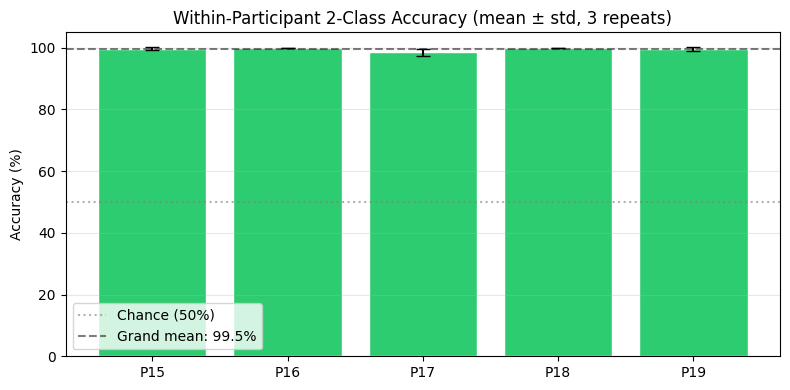

In [ ]:
# Bar chart: mean accuracy per participant with error bars
fig, ax = plt.subplots(figsize=(8, 4))

pids, means, stds = [], [], []
for pid in PARTICIPANTS:
    pid_accs = [r["acc"] * 100 for r in all_results if r["participant"] == pid]
    if pid_accs:
        pids.append(f"P{pid}")
        means.append(np.mean(pid_accs))
        stds.append(np.std(pid_accs))

colors = ["#2ecc71" if m >= 80 else "#e67e22" if m >= 60 else "#e74c3c"
          for m in means]
bars = ax.bar(pids, means, yerr=stds, capsize=5, color=colors,
              edgecolor="white", error_kw={"linewidth": 1.5})

ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 105)
ax.set_title("Within-Participant 2-Class Accuracy (mean ± std, 3 repeats)")
ax.axhline(y=50, color="grey", linestyle=":", alpha=0.6, label="Chance (50%)")
grand_mean = np.mean(means)
ax.axhline(y=grand_mean, color="black", linestyle="--", alpha=0.5,
           label=f"Grand mean: {grand_mean:.1f}%")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

---
## 11. Detailed results per repeat

Full breakdown showing every individual train/test run, including which IDs were held out.

In [ ]:
detail_rows = []
for r in all_results:
    detail_rows.append({
        "Participant": r["participant"],
        "Repeat": r["repeat"],
        "Train Windows": r["n_train"],
        "Test Windows": r["n_test"],
        "Held-out Curl IDs": str(r["held_curl_ids"]),
        "Held-out Bench IDs": str(r["held_bench_ids"]),
        "Acc (%)": r["acc"] * 100,
        "F1 (%)": r["f1"] * 100,
        "Prec (%)": r["precision"] * 100,
        "Rec (%)": r["recall"] * 100,
    })

detail_df = pd.DataFrame(detail_rows)
print("Detailed results — every participant × repeat:")
display(detail_df.round(2))

Detailed results — every participant × repeat:


,Participant,Repeat,Train Windows,Test Windows,Held-out Curl IDs,Held-out Bench IDs,Acc (%),F1 (%),Prec (%),Rec (%)
0,15,1,522,108,[np.int64(21)],"[np.int64(36), np.int64(28)]",99.07,98.88,98.44,99.35
1,15,2,532,98,[np.int64(33)],"[np.int64(38), np.int64(37)]",100.00,100.00,100.00,100.00
2,15,3,537,93,[np.int64(30)],"[np.int64(25), np.int64(36)]",100.00,100.00,100.00,100.00
3,16,1,371,55,[np.int64(49)],"[np.int64(56), np.int64(55)]",100.00,100.00,100.00,100.00
4,16,2,348,78,[np.int64(54)],"[np.int64(47), np.int64(60)]",100.00,100.00,100.00,100.00
5,16,3,371,55,[np.int64(41)],"[np.int64(45), np.int64(58)]",100.00,100.00,100.00,100.00
6,17,1,381,71,[np.int64(72)],"[np.int64(75), np.int64(73)]",100.00,100.00,100.00,100.00
7,17,2,366,86,[np.int64(71)],"[np.int64(66), np.int64(67)]",97.67,97.18,96.15,98.39
8,17,3,364,88,[np.int64(61)],"[np.int64(65), np.int64(66)]",97.73,97.38,96.55,98.36
9,18,1,355,68,[np.int64(90)],"[np.int64(81), np.int64(95)]",100.00,100.00,100.00,100.00


---
## 12. Confusion matrices per participant

For each participant, we aggregate predictions across all 3 repeats into one confusion matrix. This pools enough samples to see whether the model systematically confuses one class for the other.

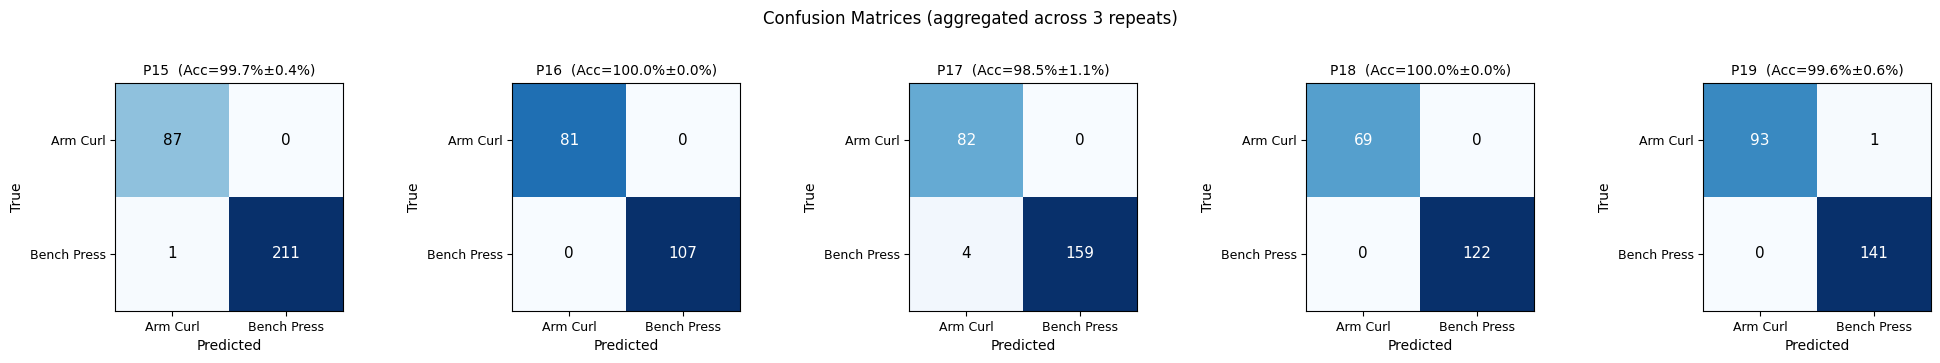

In [ ]:
n_parts = len(PARTICIPANTS)
fig, axes = plt.subplots(1, n_parts, figsize=(4 * n_parts, 3.5), squeeze=False)
axes = axes[0]

for ax, pid in zip(axes, PARTICIPANTS):
    pid_results = [r for r in all_results if r["participant"] == pid]
    if not pid_results:
        continue

    # Aggregate CM across repeats
    cm_agg = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=int)
    for r in pid_results:
        cm_agg += r["cm"]

    im = ax.imshow(cm_agg, cmap="Blues")
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(class_names, fontsize=9)
    ax.set_yticklabels(class_names, fontsize=9)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    pid_accs = [r["acc"] * 100 for r in pid_results]
    ax.set_title(f"P{pid}  (Acc={np.mean(pid_accs):.1f}%±{np.std(pid_accs):.1f}%)",
                 fontsize=10)

    thresh = cm_agg.max() / 2 if cm_agg.max() > 0 else 0
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, f"{cm_agg[i, j]}", ha="center", va="center",
                    color="white" if cm_agg[i, j] > thresh else "black",
                    fontsize=11)

plt.suptitle("Confusion Matrices (aggregated across 3 repeats)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---
## 13. Training curves

One subplot per participant showing how training and validation loss evolved across epochs. Each of the 3 repeats is plotted as a separate line so you can see whether convergence is consistent or varies with the holdout split.

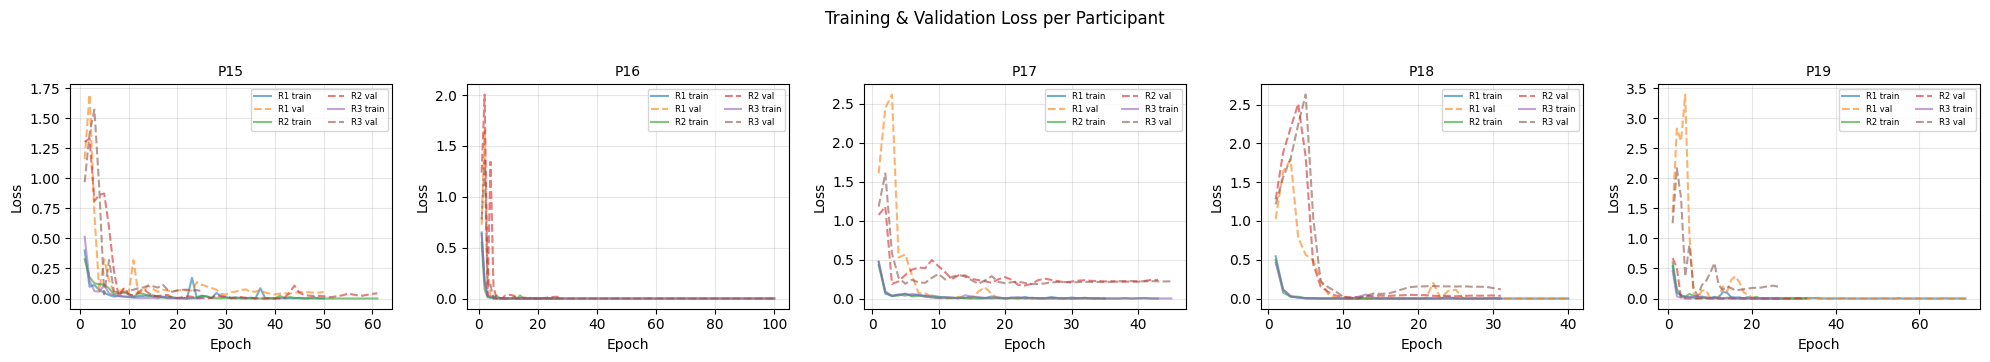

In [ ]:
fig, axes = plt.subplots(1, len(PARTICIPANTS), figsize=(4 * len(PARTICIPANTS), 3.5),
                        squeeze=False)
axes = axes[0]

for ax, pid in zip(axes, PARTICIPANTS):
    pid_results = [r for r in all_results if r["participant"] == pid]
    for r in pid_results:
        ep = range(1, len(r["history"]["train_loss"]) + 1)
        ax.plot(ep, r["history"]["train_loss"], alpha=0.6, linestyle="-",
                label=f"R{r['repeat']} train")
        ax.plot(ep, r["history"]["val_loss"], alpha=0.6, linestyle="--",
                label=f"R{r['repeat']} val")

    ax.set_title(f"P{pid}", fontsize=10)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend(fontsize=6, ncol=2)
    ax.grid(True, alpha=0.3)

plt.suptitle("Training & Validation Loss per Participant", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Results table for Master Results Spreadsheet
from sklearn.metrics import f1_score

rows = []
for pid in PARTICIPANTS:
    pid_results = [r for r in all_results if r["participant"] == pid]
    if not pid_results:
        continue

    # Pool predictions across all repeats for this participant
    y_true = np.concatenate([r["y_true"] for r in pid_results])
    y_pred = np.concatenate([r["y_pred"] for r in pid_results])

    # Per-class recall (a.k.a. per-class accuracy) and per-class F1
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    per_class_acc = cm.diagonal() / cm.sum(axis=1).clip(min=1)
    per_class_f1  = f1_score(y_true, y_pred, labels=[0, 1], average=None, zero_division=0)

    rows.append({"Participant": f"P{pid}", "Parent Class": "Arm Curl",
                 "Accuracy (%)": per_class_acc[0]*100, "F1 (%)": per_class_f1[0]*100})
    rows.append({"Participant": f"P{pid}", "Parent Class": "Bench Press",
                 "Accuracy (%)": per_class_acc[1]*100, "F1 (%)": per_class_f1[1]*100})
    rows.append({"Participant": f"P{pid}", "Parent Class": "Total",
                 "Accuracy (%)": accuracy_score(y_true, y_pred)*100,
                 "F1 (%)": f1_score(y_true, y_pred, average="macro", zero_division=0)*100})

# Grand totals: pool every prediction from every participant and repeat
y_true_all = np.concatenate([r["y_true"] for r in all_results])
y_pred_all = np.concatenate([r["y_pred"] for r in all_results])
cm_all = confusion_matrix(y_true_all, y_pred_all, labels=[0, 1])
per_class_acc_all = cm_all.diagonal() / cm_all.sum(axis=1).clip(min=1)
per_class_f1_all  = f1_score(y_true_all, y_pred_all, labels=[0, 1], average=None, zero_division=0)

rows.append({"Participant": "Total", "Parent Class": "Arm Curl",
             "Accuracy (%)": per_class_acc_all[0]*100, "F1 (%)": per_class_f1_all[0]*100})
rows.append({"Participant": "Total", "Parent Class": "Bench Press",
             "Accuracy (%)": per_class_acc_all[1]*100, "F1 (%)": per_class_f1_all[1]*100})
rows.append({"Participant": "Total", "Parent Class": "Total",
             "Accuracy (%)": accuracy_score(y_true_all, y_pred_all)*100,
             "F1 (%)": f1_score(y_true_all, y_pred_all, average="macro", zero_division=0)*100})

writeup_df = pd.DataFrame(rows)
print("Predictions pooled across all 3 repeats per participant")
display(writeup_df.round(2))

Writeup table — predictions pooled across all 3 repeats per participant


,Participant,Parent Class,Accuracy (%),F1 (%)
0,P15,Arm Curl,100.00,99.43
1,P15,Bench Press,99.53,99.76
2,P15,Total,99.67,99.60
3,P16,Arm Curl,100.00,100.00
4,P16,Bench Press,100.00,100.00
5,P16,Total,100.00,100.00
6,P17,Arm Curl,100.00,97.62
7,P17,Bench Press,97.55,98.76
8,P17,Total,98.37,98.19
9,P18,Arm Curl,100.00,100.00
